# Compute Pareto front using Optuna with GMM sampling

In [1]:
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import plotly.express as px
import plotly.graph_objects as go
from sklearn.mixture import GaussianMixture

In [2]:
import warnings
warnings.simplefilter('ignore')

## Load the models trained

In [3]:
# load the models trained

with open('./data_common/best_RF_E.pickle', mode='rb') as f:
    rf_E = pickle.load(f)

In [4]:
with open('./data_common/best_RF_density.pickle', mode='rb') as f:
    rf_density = pickle.load(f)

In [5]:
with open('./data_common/best_RF_Tg.pickle', mode='rb') as f:
    rf_Tg = pickle.load(f)

## Make (fit) GMM model using the source data

In [6]:
# Load the source dataset

df_source_o = pd.read_csv('data_common/df_source.csv')
df_source = df_source_o.iloc[:, 2:9]

print(df_source.shape)
df_source.head()

(594, 7)


,SiO2,B2O3,Al2O3,MgO,CaO,Na2O,K2O
0,71.01,0.45,0.31,0.0,13.01,12.13,3.08
1,71.77,11.09,0.25,0.0,0.00,9.76,6.29
2,75.01,0.00,0.00,0.0,10.69,14.30,0.00
3,69.93,5.08,0.00,0.0,10.71,14.29,0.00
4,52.50,24.30,0.00,0.0,0.00,23.20,0.00


In [7]:
# observe df_source

df_source_stat = df_source.describe().T
df_source_stat

,count,mean,std,min,25%,50%,75%,max
SiO2,594.0,66.193990,9.866657,10.0,60.500,67.500,72.5450,83.43
B2O3,594.0,3.912172,7.974995,0.0,0.000,0.000,4.9975,50.00
Al2O3,594.0,4.686911,4.542199,0.0,0.000,2.965,8.0000,21.00
MgO,594.0,5.190084,4.992419,0.0,0.000,5.000,9.3075,22.98
CaO,594.0,4.368636,6.166167,0.0,0.000,0.400,7.9975,33.33
Na2O,594.0,14.346549,6.801070,0.0,10.485,14.000,18.5975,41.90
K2O,594.0,1.000832,2.471885,0.0,0.000,0.000,0.6000,20.00


In [8]:
# get mins and maxs of compositions

comp_min = list(df_source_stat['min'])
comp_max = list(df_source_stat['max'])

comp_min_appx = [round(x, 0) for x in comp_min]
comp_max_appx = [round(x, 0) + 1.0 for x in comp_max]

print('mins  = ', comp_min_appx)
print('maxes = ', comp_max_appx)

mins  =  [10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
maxes =  [84.0, 51.0, 22.0, 24.0, 34.0, 43.0, 21.0]


In [9]:
# scaling function

def scaling(df_source):
    df_sc = (df_source - df_source.mean(axis=0)) / df_source.std(axis=0)

    return df_sc

In [10]:
# Scaling

df_sc = scaling(df_source)

print(df_sc.shape)
df_sc.head()

(594, 7)


,SiO2,B2O3,Al2O3,MgO,CaO,Na2O,K2O
0,0.488110,-0.434128,-0.963610,-1.039593,1.401416,-0.325912,0.841126
1,0.565137,0.900042,-0.976820,-1.039593,-0.708485,-0.674386,2.139730
2,0.893515,-0.490555,-1.031859,-1.039593,1.025169,-0.006844,-0.404886
3,0.378650,0.146436,-1.031859,-1.039593,1.028413,-0.008315,-0.404886
4,-1.387906,2.556469,-1.031859,-1.039593,-0.708485,1.301773,-0.404886


## Search the best fit in distributions through BIC

In [11]:
np.random.seed(1)

max_number_of_components = 7
covariance_types = ['full', 'diag', 'tied', 'spherical']
bic_values = np.empty([max_number_of_components, len(covariance_types)])

In [12]:
# grid search using BIC

for covariance_type_index, covariance_type in enumerate(covariance_types):
    for number_of_components in range(max_number_of_components):
        gmm_model = GaussianMixture(n_components = number_of_components + 1, covariance_type = covariance_type)
        gmm_model.fit(df_sc)
        bic_values[number_of_components, covariance_type_index] = gmm_model.bic(df_sc)

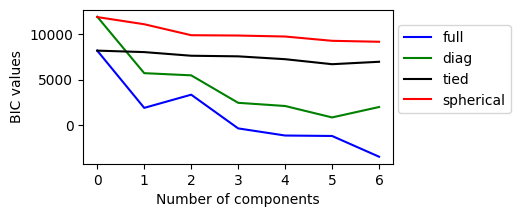

In [13]:
# comapre BIC

plt.figure(figsize=(4, 2))

plt.plot(bic_values[:, 0], 'b-', label='full')
plt.plot(bic_values[:, 1], 'g-', label='diag')
plt.plot(bic_values[:, 2], 'k-', label='tied')
plt.plot(bic_values[:, 3], 'r-', label='spherical')

plt.xlabel('Number of components')
plt.ylabel('BIC values')
plt.legend(bbox_to_anchor=(0.88, 0.9, 0.5, 0.001), borderaxespad=0., )
plt.show()

In [14]:
# Optimal parameters

optimal_index = np.where(bic_values == bic_values.min())
optimal_number_of_components = optimal_index[0][0] + 1
optimal_covariance_type = covariance_types[optimal_index[1][0]]

print('optimal covariance type =', optimal_covariance_type)

optimal covariance type = full


In [15]:
# the best GMM model

gmm = GaussianMixture(n_components = optimal_number_of_components, covariance_type = optimal_covariance_type, random_state = 0)
gmm.fit(df_sc)

,"n_components n_components: int, default=1The number of mixture components.",np.int64(7)
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0


## Search in interpolation area of the source data

In [16]:
# objective function

def objective(trial):
    # define search ranges for each composition
    sio2 = trial.suggest_float("SiO2",   comp_min_appx[0], comp_max_appx[0])
    b2o3 = trial.suggest_float("B2O3",   comp_min_appx[1], comp_max_appx[1])
    al2o3 = trial.suggest_float("Al2O3", comp_min_appx[2], comp_max_appx[2])
    mgo = trial.suggest_float("MgO",     comp_min_appx[3], comp_max_appx[3])
    cao = trial.suggest_float("CaO",     comp_min_appx[4], comp_max_appx[4])
    na2o = trial.suggest_float("Na2O",   comp_min_appx[5], comp_max_appx[5])
    k2o = trial.suggest_float("K2O",     comp_min_appx[6], comp_max_appx[6])

    # adjust total = 100%
    total = sio2 + b2o3 + al2o3 + mgo + cao + na2o + k2o    
    composition = 100.0 * np.array([sio2/total, b2o3/total, al2o3/total, mgo/total, cao/total, na2o/total, k2o/total]).reshape(1, -1)

    # scaling for gmm check
    composition_sc = np.zeros(df_source.shape[1]).reshape(1, df_source.shape[1])
    for i in range(df_source.shape[1]):
        element_sc = (composition[0, i] - df_source_stat.iloc[i, 1]) / df_source_stat.iloc[i, 2]
        composition_sc[0, i] = element_sc
    
    # compute log likelihood to judge inter / extrapolation
    log_likelihood = gmm.score_samples(composition_sc)[0]
    # print(log_likelihood)
    
    # if log likelihood is less than the THRESHOLD, give penalty as extrapolation
    THRESHOLD = -70.0 
    if log_likelihood < THRESHOLD:    
        return -1e10, -1e10, 1e10    # give opposite penalty for maximize / maximize / minimize
    
    # predict if interpolation without scaling because model is random forest trained unscaled data
    e_pred = rf_E.predict(composition)[0]
    density_pred = rf_density.predict(composition)[0]
    tg_pred = rf_Tg.predict(composition)[0]
    
    return e_pred, density_pred, tg_pred

In [17]:
# determine optimazion conditions : E(maximize), density(maximize), Tg(minimize)

study = optuna.create_study(directions=["maximize", "maximize", "minimize"])

[I 2026-09-26 16:18:23,913] A new study created in memory with name: no-name-faa56132-8b52-45e2-89c4-76c07452db31


In [18]:
# profibit showing log

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [19]:
# optimization process

study.optimize(objective, n_trials=100)

In [20]:
# print results

pareto_front = study.best_trials
print(f"nunber of Pareto fronts = {len(pareto_front)}")

nunber of Pareto fronts = 16


In [21]:
# make table of the results

df_pareto_opt_comp = pd.DataFrame()

for trial in pareto_front:
    params = np.array(list(trial.params.values()))
    normalized_comp = pd.DataFrame(100.0 * params / np.sum(params)).T
    comp_target = pd.concat([normalized_comp, pd.DataFrame(trial.values).T], axis = 1)    
    df_pareto_opt_comp = pd.concat([df_pareto_opt_comp, comp_target])

df_pareto_opt_comp.columns = ["SiO2", "B2O3", "Al2O3", "MgO", "CaO", "Na2O", "K2O", "E", "density", "Tg"]
print(df_pareto_opt_comp.shape)
df_pareto_opt_comp.head()

(16, 10)


,SiO2,B2O3,Al2O3,MgO,CaO,Na2O,K2O,E,density,Tg
0,35.156689,25.005425,1.844326,5.280554,2.291997,21.713155,8.707854,73.066449,2.495486,516.704932
0,42.897460,4.246932,1.071984,7.393631,16.509885,18.103446,9.776661,77.305294,2.626600,550.718963
0,23.903515,21.116383,3.999370,9.909637,13.316481,24.000917,3.753696,77.254561,2.580588,527.377976
0,23.794221,20.069833,4.933154,10.283123,16.582607,12.689835,11.647227,77.077798,2.599840,542.372449
0,31.885844,0.771749,13.530631,3.631709,32.699313,2.886487,14.594267,79.244525,2.708731,607.892857


In [22]:
# check

# df_pareto_opt_comp.iloc[:, 0:7].sum(axis=1)

In [23]:
# visualization

all_values = np.array([t.values for t in study.trials])           # targets from all study
pareto_values = np.array([t.values for t in study.best_trials])   # targets optimized

df_all_values = pd.DataFrame(all_values, columns = ['E', 'density', 'Tg'])        # targets from all study
df_pareto_values = pd.DataFrame(pareto_values, columns = ['E', 'density', 'Tg'])  # targets optimized
df_all_values['group'] = 'All'                                                    # add groups
df_pareto_values['group'] = 'Pareto'
df = pd.concat([df_all_values, df_pareto_values])

fig = px.scatter_3d(df, x='E', y='density', z='Tg', color='group', width=800, height=600)   # 3d plot
fig.update_layout(margin = dict(l=0, r=0, b=20, t=20))       # margins to depict

fig.update_traces(marker = dict(size = 3))
fig.show()

## Save the final results for comparison

In [24]:
# save the dataframe

df_pareto_opt_comp.to_csv('./data_common/df_pareto_opt_comp_gmm.csv', index = False)